In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# 데이터 로딩
df = pd.read_csv('ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv')
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(235468, 11)
     month        town flat_type block        street_name storey_range  \
0  2017-01  ANG MO KIO    2 ROOM   406  ANG MO KIO AVE 10     10 TO 12   
1  2017-01  ANG MO KIO    3 ROOM   108   ANG MO KIO AVE 4     01 TO 03   
2  2017-01  ANG MO KIO    3 ROOM   602   ANG MO KIO AVE 5     01 TO 03   
3  2017-01  ANG MO KIO    3 ROOM   465  ANG MO KIO AVE 10     04 TO 06   
4  2017-01  ANG MO KIO    3 ROOM   601   ANG MO KIO AVE 5     01 TO 03   

   floor_area_sqm      flat_model  lease_commence_date     remaining_lease  \
0            44.0        Improved                 1979  61 years 04 months   
1            67.0  New Generation                 1978  60 years 07 months   
2            67.0  New Generation                 1980  62 years 05 months   
3            68.0  New Generation                 1980   62 years 01 month   
4            67.0  New Generation                 1980  62 years 05 months   

   resale_price  
0      232000.0  
1      250000.0  
2      262000.0  
3

In [2]:
# 날짜 변환
df['month'] = pd.to_datetime(df['month'])

# TEL 3단계 개통: 2022년 11월
treatment_date = pd.Timestamp('2022-11-01')

# TEL 3단계 신규역 근처 town (처리 집단)
# Tanjong Rhu, Katong Park, Tanjong Katong, Marine Parade, Marine Terrace, Siglap, Bayshore
treated_towns = ['MARINE PARADE', 'BEDOK', 'TAMPINES']

# 통제 집단: TEL과 거리가 먼 town
control_towns = ['BUKIT BATOK', 'CHOA CHU KANG', 'JURONG EAST', 'BUKIT PANJANG']

# 처리/통제 집단 필터링
df_did = df[df['town'].isin(treated_towns + control_towns)].copy()
df_did['treated'] = df_did['town'].isin(treated_towns).astype(int)
df_did['post'] = (df_did['month'] >= treatment_date).astype(int)
df_did['did'] = df_did['treated'] * df_did['post']

# 월별 평균 가격 집계
monthly = df_did.groupby(['month', 'treated'])['resale_price'].mean().reset_index()
monthly.columns = ['month', 'treated', 'avg_price']

print(f"처리 집단 거래 수: {df_did[df_did['treated']==1].shape[0]}")
print(f"통제 집단 거래 수: {df_did[df_did['treated']==0].shape[0]}")
print(f"\n처리 집단 towns: {treated_towns}")
print(f"통제 집단 towns: {control_towns}")
print(monthly.tail(10))

처리 집단 거래 수: 29896
통제 집단 거래 수: 33760

처리 집단 towns: ['MARINE PARADE', 'BEDOK', 'TAMPINES']
통제 집단 towns: ['BUKIT BATOK', 'CHOA CHU KANG', 'JURONG EAST', 'BUKIT PANJANG']
         month  treated      avg_price
220 2026-03-01        0  610823.301656
221 2026-03-01        1  660644.975207
222 2026-04-01        0  617119.055738
223 2026-04-01        1  674728.853741
224 2026-05-01        0  606817.878125
225 2026-05-01        1  691471.282313
226 2026-06-01        0  606301.642140
227 2026-06-01        1  669264.731183
228 2026-07-01        0  602020.860825
229 2026-07-01        1  685941.988636


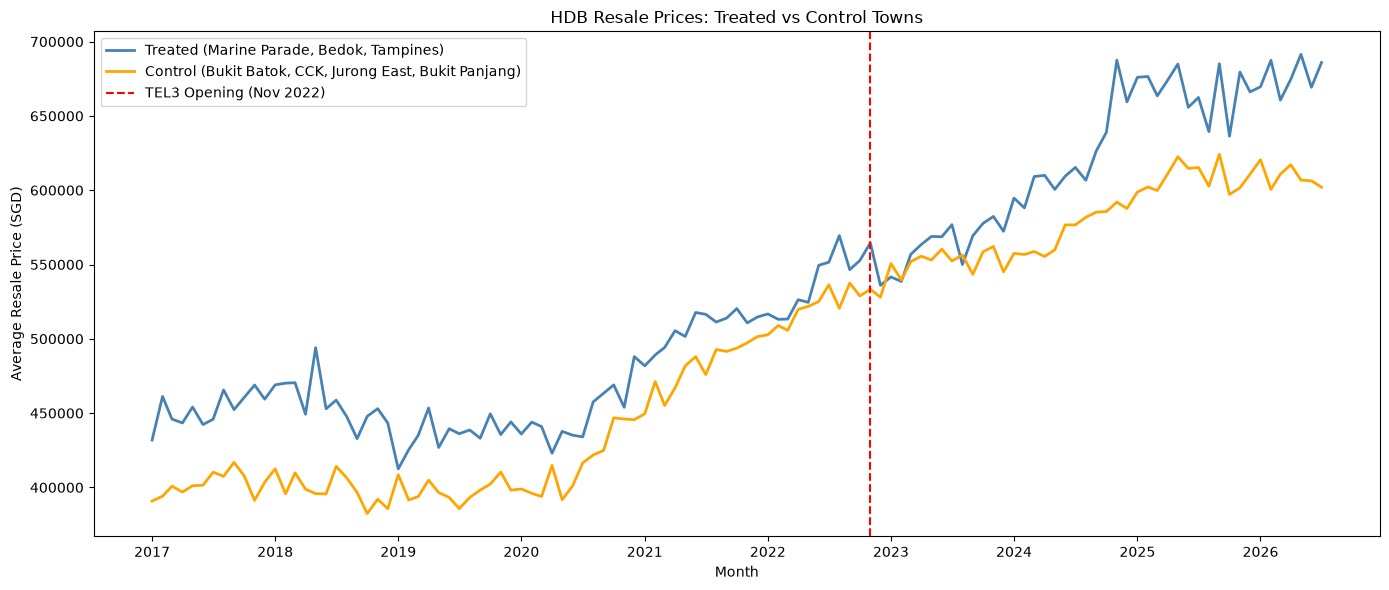

                            OLS Regression Results                            
Dep. Variable:           resale_price   R-squared:                       0.773
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                 4.335e+04
Date:                Wed, 15 Jul 2026   Prob (F-statistic):               0.00
Time:                        09:40:23   Log-Likelihood:            -8.0875e+05
No. Observations:               63656   AIC:                         1.618e+06
Df Residuals:                   63650   BIC:                         1.618e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -8.797e+06   5

In [3]:
# 처리/통제 집단 트렌드 시각화
treated_monthly = monthly[monthly['treated'] == 1]
control_monthly = monthly[monthly['treated'] == 0]

plt.figure(figsize=(14, 6))
plt.plot(treated_monthly['month'], treated_monthly['avg_price'], 
         label='Treated (Marine Parade, Bedok, Tampines)', linewidth=2, color='steelblue')
plt.plot(control_monthly['month'], control_monthly['avg_price'], 
         label='Control (Bukit Batok, CCK, Jurong East, Bukit Panjang)', linewidth=2, color='orange')
plt.axvline(x=treatment_date, color='red', linestyle='--', linewidth=1.5, label='TEL3 Opening (Nov 2022)')
plt.title('HDB Resale Prices: Treated vs Control Towns')
plt.xlabel('Month')
plt.ylabel('Average Resale Price (SGD)')
plt.legend()
plt.tight_layout()
plt.savefig('fig_01_parallel_trends.png', dpi=150, bbox_inches='tight')
plt.show()

# DiD 회귀분석
model = smf.ols('resale_price ~ treated + post + did + floor_area_sqm + lease_commence_date', 
                data=df_did).fit()
print(model.summary())

# 핵심 결과
did_coef = model.params['did']
did_pvalue = model.pvalues['did']
print(f"\n=== DiD 핵심 결과 ===")
print(f"TEL3 개통 인과 효과: SGD {did_coef:,.0f}")
print(f"P-value: {did_pvalue:.4f}")
print(f"통계적 유의성: {'유의함 (p<0.05)' if did_pvalue < 0.05 else '유의하지 않음 (p>=0.05)'}")

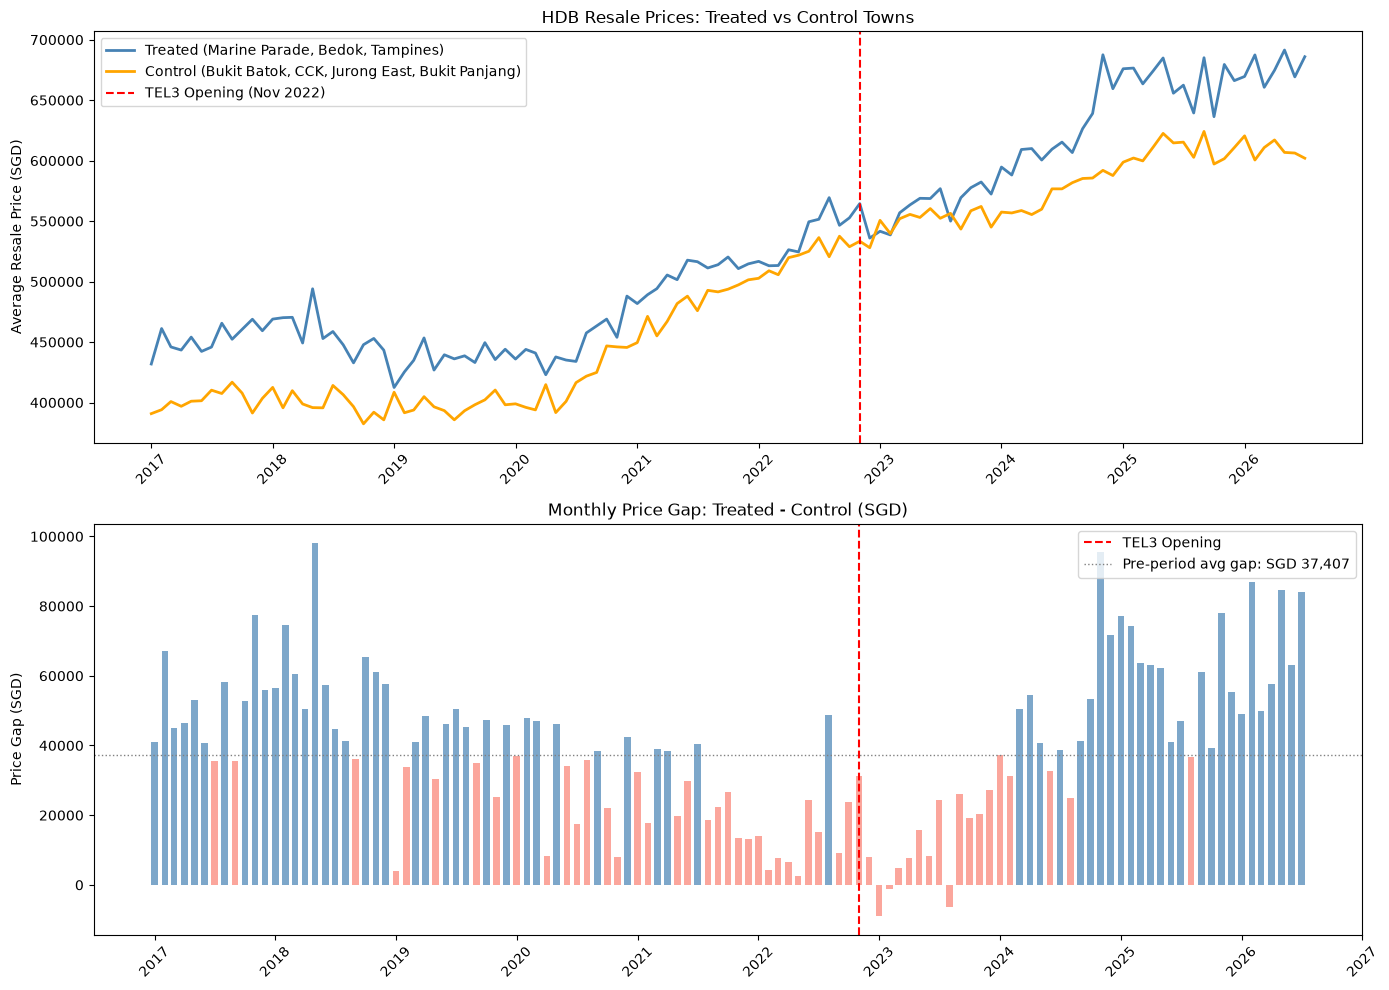

개통 전 평균 가격 격차: SGD 37,407
개통 후 평균 가격 격차: SGD 42,735
격차 변화: SGD 5,328


In [4]:
# 월별 처리-통제 집단 가격 격차
treated_m = monthly[monthly['treated'] == 1].set_index('month')['avg_price']
control_m = monthly[monthly['treated'] == 0].set_index('month')['avg_price']
gap = (treated_m - control_m).reset_index()
gap.columns = ['month', 'price_gap']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 상단: 처리 vs 통제 트렌드
axes[0].plot(treated_monthly['month'], treated_monthly['avg_price'],
             label='Treated (Marine Parade, Bedok, Tampines)', linewidth=2, color='steelblue')
axes[0].plot(control_monthly['month'], control_monthly['avg_price'],
             label='Control (Bukit Batok, CCK, Jurong East, Bukit Panjang)', linewidth=2, color='orange')
axes[0].axvline(x=treatment_date, color='red', linestyle='--', linewidth=1.5, label='TEL3 Opening (Nov 2022)')
axes[0].set_title('HDB Resale Prices: Treated vs Control Towns')
axes[0].set_ylabel('Average Resale Price (SGD)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# 하단: 가격 격차
pre_gap_mean = gap[gap['month'] < treatment_date]['price_gap'].mean()
colors = ['steelblue' if x >= pre_gap_mean else 'salmon' for x in gap['price_gap']]
axes[1].bar(gap['month'], gap['price_gap'], color=colors, alpha=0.7, width=20)
axes[1].axvline(x=treatment_date, color='red', linestyle='--', linewidth=1.5, label='TEL3 Opening')
axes[1].axhline(y=pre_gap_mean, color='gray', linestyle=':', linewidth=1, label=f'Pre-period avg gap: SGD {pre_gap_mean:,.0f}')
axes[1].set_title('Monthly Price Gap: Treated - Control (SGD)')
axes[1].set_ylabel('Price Gap (SGD)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig_02_price_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"개통 전 평균 가격 격차: SGD {pre_gap_mean:,.0f}")
post_gap_mean = gap[gap['month'] >= treatment_date]['price_gap'].mean()
print(f"개통 후 평균 가격 격차: SGD {post_gap_mean:,.0f}")
print(f"격차 변화: SGD {post_gap_mean - pre_gap_mean:,.0f}")

In [5]:
print("=" * 50)
print("HDB Resale Price — TEL3 Causal Impact (DiD)")
print("=" * 50)
print(f"\n분석 기간: 2017-01 ~ 2026-07")
print(f"이벤트: TEL3 개통 (2022년 11월)")
print(f"처리 집단: Marine Parade, Bedok, Tampines")
print(f"통제 집단: Bukit Batok, CCK, Jurong East, Bukit Panjang")
print(f"\n--- DiD 회귀 결과 ---")
print(f"전체 시장 상승 효과 (post):     SGD {model.params['post']:,.0f} (p<0.001)")
print(f"처리 집단 기본 프리미엄 (treated): SGD {model.params['treated']:,.0f} (p<0.001)")
print(f"TEL3 인과 효과 (did):           SGD {model.params['did']:,.0f} (p={model.pvalues['did']:.3f})")
print(f"\n--- 가격 격차 분석 ---")
print(f"개통 전 평균 가격 격차: SGD {pre_gap_mean:,.0f}")
print(f"개통 후 평균 가격 격차: SGD {post_gap_mean:,.0f}")
print(f"격차 변화:             SGD {post_gap_mean - pre_gap_mean:,.0f}")
print(f"\n--- 결론 ---")
print(f"TEL3 개통의 인과 효과는 통계적으로 유의하지 않음 (p=0.463)")
print(f"그러나 방향성은 양수 (+SGD 5,328 격차 증가)")
print(f"2022-2023년 싱가포르 전체 HDB 시장 급등이 지역 효과를 압도한 것으로 해석")
print(f"R-squared: {model.rsquared:.3f} — 면적·잔여리스가 가격의 77% 설명")

HDB Resale Price — TEL3 Causal Impact (DiD)

분석 기간: 2017-01 ~ 2026-07
이벤트: TEL3 개통 (2022년 11월)
처리 집단: Marine Parade, Bedok, Tampines
통제 집단: Bukit Batok, CCK, Jurong East, Bukit Panjang

--- DiD 회귀 결과 ---
전체 시장 상승 효과 (post):     SGD 140,470 (p<0.001)
처리 집단 기본 프리미엄 (treated): SGD 94,279 (p<0.001)
TEL3 인과 효과 (did):           SGD -942 (p=0.463)

--- 가격 격차 분석 ---
개통 전 평균 가격 격차: SGD 37,407
개통 후 평균 가격 격차: SGD 42,735
격차 변화:             SGD 5,328

--- 결론 ---
TEL3 개통의 인과 효과는 통계적으로 유의하지 않음 (p=0.463)
그러나 방향성은 양수 (+SGD 5,328 격차 증가)
2022-2023년 싱가포르 전체 HDB 시장 급등이 지역 효과를 압도한 것으로 해석
R-squared: 0.773 — 면적·잔여리스가 가격의 77% 설명
